# HIV-1 蛋白酶批量对接与虚筛方法学验证

同一个靶点、同一受体、同一盒子、同一批配体，把 **AutoDock Vina 1.2.7** 和 **Interformer** 摆在一起跑，
看两边在位姿复现、判别富集、打分与实测活性的相关性三件事上各是什么表现。

本 Notebook 只做结果展示，读取 `results/` 里已经算好的 csv 和 json，不重跑对接。
全部数字都能用 `bash scripts/run_all.sh` 从零复现。

- 靶点：HIV-1 蛋白酶（RCSB 1XL2，1.50 Å）
- 配体库：30 阳性 + 40 实测阴性 + 130 诱饵 + 1 晶体参考配体
- 引擎：AutoDock Vina 1.2.7（经验打分）、Interformer（学习型能量函数）

## 1. 配置与数据规模

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

# 定位项目根目录。Notebook 放在仓库根目录，也允许从 notebooks/ 打开
ROOT = Path.cwd()
if not (ROOT / 'results').exists() and (ROOT.parent / 'results').exists():
    ROOT = ROOT.parent
assert (ROOT / 'results').exists(), '找不到 results/，请在项目根目录打开本 Notebook'

# 解析极简 config.txt（key = value）
cfg = {}
for line in (ROOT / 'config.txt').read_text(encoding='utf-8').splitlines():
    line = line.split('#', 1)[0].strip()
    if '=' in line:
        k, v = line.split('=', 1)
        cfg[k.strip()] = v.strip()

metrics = json.loads((ROOT / 'results' / 'metrics.json').read_text(encoding='utf-8'))

print('靶点      :', cfg.get('target_name'))
print('配体库    : %s 阳性 / %s 实测阴性 / %s 诱饵' % (cfg['n_positives'], cfg['n_negatives'], cfg['n_decoys']))
print('对接参数  : exhaustiveness=%s, n_poses=%s, workers=%s, vina_seed=%s'
      % (cfg['exhaustiveness'], cfg['n_poses'], cfg['workers'], cfg['vina_seed']))
print('盒子      : 晶体配体包围盒 + %s Å padding，最小边长 %s Å' % (cfg['box_padding'], cfg['box_min_size']))
print('指标覆盖  :', metrics['n_molecules'])

靶点      : HIV-1 protease
配体库    : 30 阳性 / 40 实测阴性 / 130 诱饵
对接参数  : exhaustiveness=8, n_poses=5, workers=8, vina_seed=42
盒子      : 晶体配体包围盒 + 6.0 Å padding，最小边长 20.0 Å
指标覆盖  : {'positive': 30, 'negative': 40, 'decoy': 130}


## 2. 数据与打分

`results/scores_merged.csv` 把每张分子的分组、理化性质、Vina 打分、Interformer 预测拼在一张表里。

诱饵和实测阴性要分开看。诱饵是「看着像药，但没测过」；实测阴性是「看着像药、测过、确实不结合」。
一个只在阳性对诱饵上好看的打分函数，一换成实测阴性就塌掉的，说明它认的只是理化性质，不是相互作用。

In [2]:
merged = pd.read_csv(ROOT / 'results' / 'scores_merged.csv')
vina = pd.read_csv(ROOT / 'results' / 'vina_scores.csv')
inter = pd.read_csv(ROOT / 'results' / 'interformer_scores.csv')

print('scores_merged.csv 维度 :', merged.shape)
print('Vina 覆盖配体数        :', vina['ligand_id'].nunique(), '（含参考配体 1xl2_ref）')
print('Interformer 覆盖配体数 :', inter['ligand_id'].nunique(), '（只跑阳性+实测阴性，不含诱饵）')

summary = merged.groupby('group').agg(
    分子数=('ligand_id', 'count'),
    重原子中位=('heavy_atoms', 'median'),
    Vina_中位打分=('vina_affinity', 'median'),
    Interformer_中位_pIC50=('pred_pIC50', 'median'),
).reindex(['positive', 'negative', 'decoy'])
summary

scores_merged.csv 维度 : (200, 22)
Vina 覆盖配体数        : 201 （含参考配体 1xl2_ref）
Interformer 覆盖配体数 : 71 （只跑阳性+实测阴性，不含诱饵）


,分子数,重原子中位,Vina_中位打分,Interformer_中位_pIC50
group,,,,
positive,30,37.0,-8.0555,7.432617
negative,40,24.0,-7.5570,5.197754
decoy,130,34.0,-8.2025,NaN


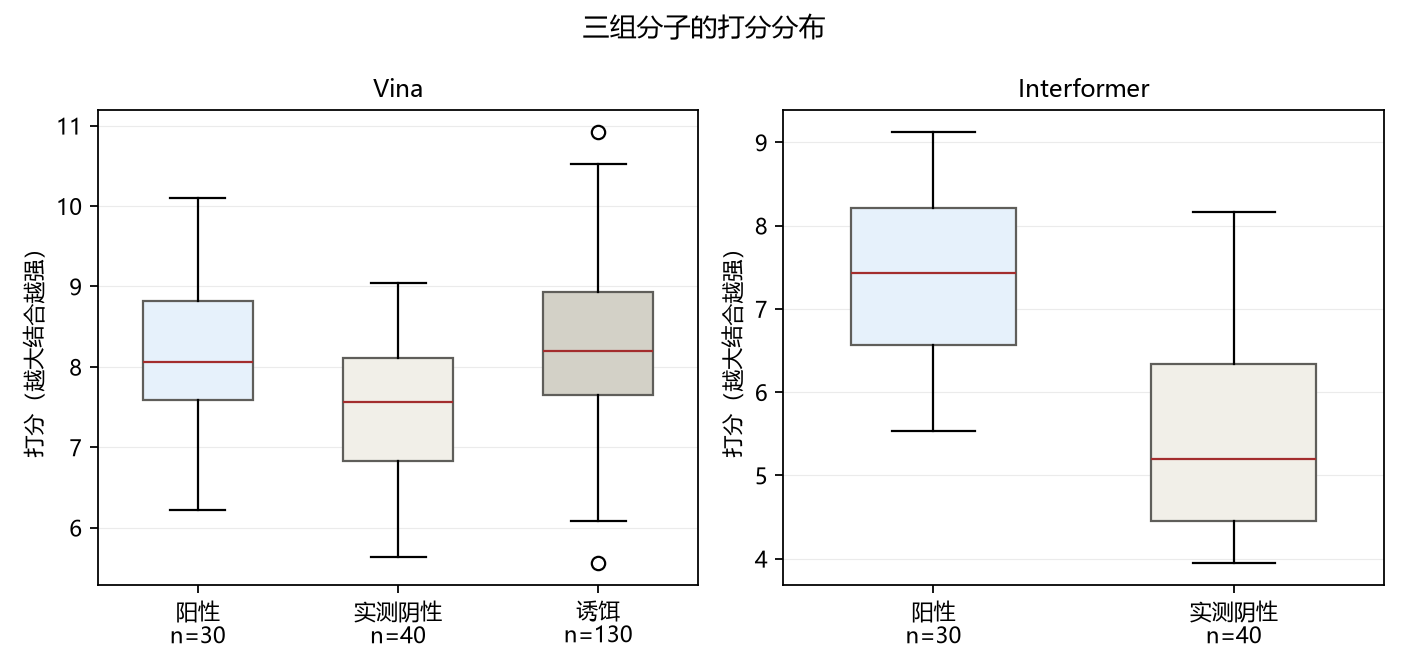

In [3]:
display(Image(filename=str(ROOT / 'results' / 'figures' / 'score_distributions.png')))

## 3. 检验一 位姿复现

把晶体配体从口袋里取出来重新对接，看能不能回到晶体里那个位置。判据是重原子 RMSD ≤ 2.0 Å。

In [4]:
pr = metrics['pose_reproduction']
pose_tbl = pd.DataFrame([
    {'引擎': 'AutoDock Vina', '位姿复现 RMSD (Å)': pr['Vina']['redock_rmsd'],
     '判据 ≤2.0 Å': '通过' if pr['Vina']['pass_2A'] else '未通过'},
    {'引擎': 'Interformer（MC 采样）',
     '位姿复现 RMSD (Å)': round(pr['Interformer']['best_sampled_rmsd'], 2),
     '判据 ≤2.0 Å': '通过' if pr['Interformer']['n_within_2A'] > 0 else '未通过'},
])
print('Interformer 采样 %d 条候选，剔除保留下来的输入构象后最好 %.2f Å，没有一条 ≤2 Å'
      % (pr['Interformer']['n_poses_generated'] - 1, pr['Interformer']['best_sampled_rmsd']))
pose_tbl

Interformer 采样 20 条候选，剔除保留下来的输入构象后最好 2.70 Å，没有一条 ≤2 Å


,引擎,位姿复现 RMSD (Å),判据 ≤2.0 Å
0,AutoDock Vina,2.55,未通过
1,Interformer（MC 采样）,2.70,未通过


## 4. 检验二 判别富集

阳性、实测阴性、诱饵混成一个库，看打分能不能把真活性物排到前面。
指标是 ROC-AUC、AUPRC、EF1/5/10% 和 BEDROC(α=20)。所有打分统一成数值越大表示结合越强。

In [5]:
disc = metrics['discrimination']
label = {'pos_vs_neg': '阳性 vs 实测阴性', 'pos_vs_decoy': '阳性 vs 诱饵', 'pos_vs_all': '阳性 vs 阴性+诱饵'}
rows = []
for comp, per_eng in disc.items():
    for eng, m in per_eng.items():
        rows.append({'比较': label[comp], '引擎': eng, 'n': m['n'], 'n阳性': m['n_positive'],
                     'ROC-AUC': m['roc_auc'], 'AUPRC': m['auprc'],
                     'EF1%': m['ef1'], 'EF5%': m['ef5'], 'EF10%': m['ef10'], 'BEDROC20': m['bedroc20']})
disc_tbl = pd.DataFrame(rows)
disc_tbl

,比较,引擎,n,n阳性,ROC-AUC,AUPRC,EF1%,EF5%,EF10%,BEDROC20
0,阳性 vs 实测阴性,Vina,70,30,0.679,0.651,2.333,2.333,2.000,0.865
1,阳性 vs 实测阴性,Interformer,70,30,0.876,0.844,2.333,2.333,2.333,0.972
2,阳性 vs 诱饵,Vina,160,30,0.440,0.173,0.000,0.667,0.667,0.126
3,阳性 vs 阴性+诱饵,Vina,200,30,0.496,0.157,0.000,0.667,1.000,0.138
4,阳性 vs 阴性+诱饵,Interformer,70,30,0.876,0.844,2.333,2.333,2.333,0.972


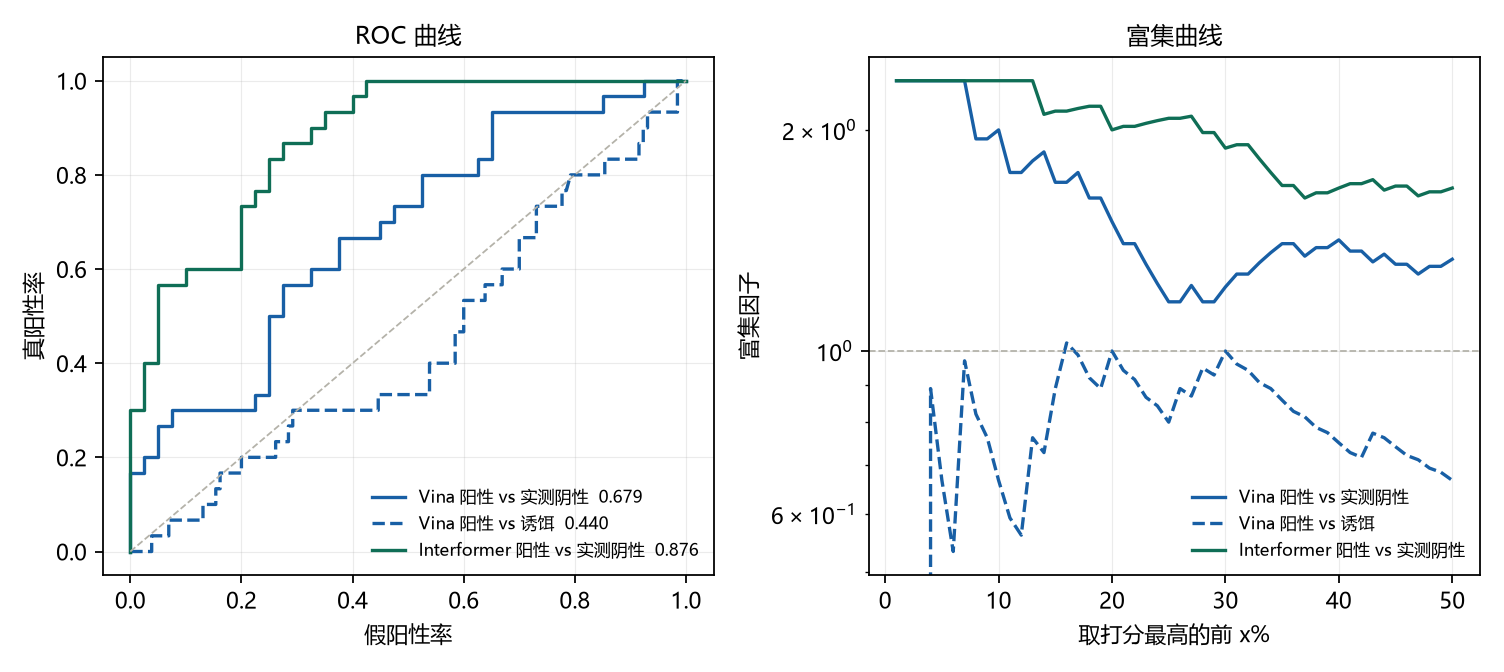

In [6]:
display(Image(filename=str(ROOT / 'results' / 'figures' / 'roc_enrichment.png')))

## 5. 检验三 打分与实测活性的相关性

只在 30 个阳性内部算，看对接打分跟实测 pActivity 对不对得上。
另外算一份按重原子数归一化的版本，用来判断这个正相关里有多少是「分子越大分越好」撑起来的。

In [7]:
corr = metrics['correlation']
rows = []
for eng, m in corr.items():
    rows.append({'引擎': eng, 'n': m['n'], 'Spearman ρ': m['spearman_rho'], 'p 值': m['spearman_p'],
                 'Pearson r': m['pearson_r'], 'R²': m['r2'], 'RMSE(pActivity)': m['rmse_pactivity'],
                 '按重原子归一 ρ': m['spearman_rho_size_normalised']})
corr_tbl = pd.DataFrame(rows)
corr_tbl

,引擎,n,Spearman ρ,p 值,Pearson r,R²,RMSE(pActivity),按重原子归一 ρ
0,Vina,30,0.360,0.0508,0.416,0.173,1.312,-0.326
1,Interformer,30,0.434,0.0165,0.436,0.190,1.299,-0.476


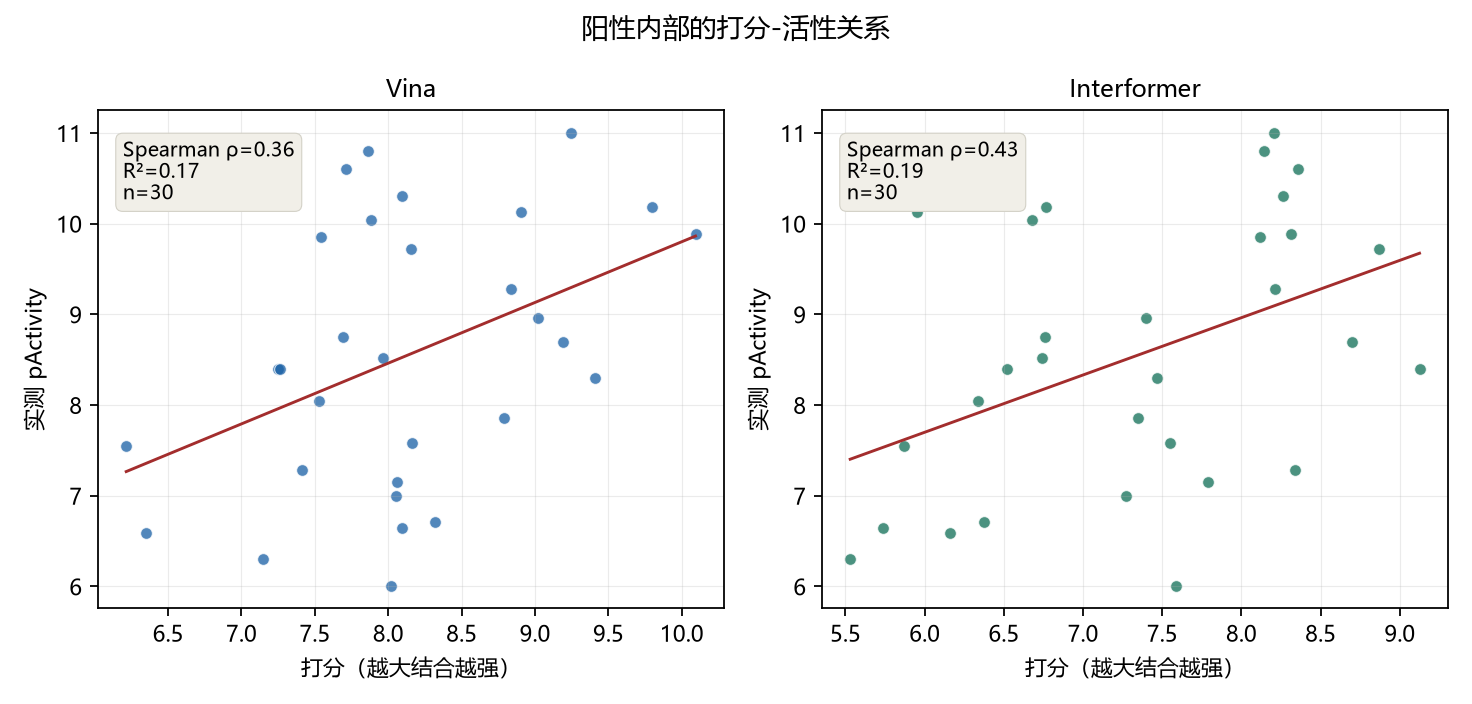

In [8]:
display(Image(filename=str(ROOT / 'results' / 'figures' / 'correlation.png')))

## 6. 结论

下面的汇总由本 Notebook 直接读取计算结果生成。完整讨论、与完整版项目的差异、以及踩过的坑，都在仓库 `README.md`。

In [9]:
print('=' * 64)
print('结论汇总')
print('=' * 64)
print('1. 位姿复现 : Vina %.2f Å、Interformer %.2f Å，都没回到晶体构象（判据 ≤2 Å）'
      % (pr['Vina']['redock_rmsd'], pr['Interformer']['best_sampled_rmsd']))
print('2. 判别富集 : 阳性 vs 实测阴性，Vina AUC=%.3f、Interformer AUC=%.3f'
      % (disc['pos_vs_neg']['Vina']['roc_auc'], disc['pos_vs_neg']['Interformer']['roc_auc']))
print('              阳性 vs 诱饵，Vina AUC=%.3f（低于随机 0.5）'
      % disc['pos_vs_decoy']['Vina']['roc_auc'])
print('3. 相关性   : Vina ρ=%.2f、Interformer ρ=%.2f'
      % (corr['Vina']['spearman_rho'], corr['Interformer']['spearman_rho']))
print('              按重原子归一后都翻负（%.2f / %.2f），正相关大半来自分子大小'
      % (corr['Vina']['spearman_rho_size_normalised'],
         corr['Interformer']['spearman_rho_size_normalised']))
print('=' * 64)

结论汇总
1. 位姿复现 : Vina 2.55 Å、Interformer 2.70 Å，都没回到晶体构象（判据 ≤2 Å）
2. 判别富集 : 阳性 vs 实测阴性，Vina AUC=0.679、Interformer AUC=0.876
              阳性 vs 诱饵，Vina AUC=0.440（低于随机 0.5）
3. 相关性   : Vina ρ=0.36、Interformer ρ=0.43
              按重原子归一后都翻负（-0.33 / -0.48），正相关大半来自分子大小


## 7. 复现

```bash
conda activate vsbench
bash scripts/run_all.sh                 # 全流程，本机 8 进程约 45 分钟
jupyter nbconvert --to notebook --execute vs_results.ipynb --inplace
```

只用已有结果的话，直接打开本 Notebook 运行即可，不碰对接。